In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, classification_report, mean_squared_error
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import tabulate


In [2]:
def train_forest(estimators, depth, X_train, y_train, X_test, y_test, class_labels, n_components):
    rf_model = RandomForestClassifier(n_estimators=estimators, max_depth=depth, random_state=42, class_weight='balanced')
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    
    # Compute metrics
    conf_matrix = confusion_matrix(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    sensitivity = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    # Specificity calculation
    specificity_list = []
    for i in range(len(conf_matrix)):
        tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
        fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_list.append(specificity)
    specificity = np.mean(specificity_list)
    
    print(f"Accuracy: {accuracy:.4f}\nSensitivity: {sensitivity:.4f}\nSpecificity: {specificity:.4f}\nF1 Score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Random Forest (n={estimators}, depth={depth}, n_components={n_components}) - Confusion Matrix")
    plt.show()
    
    return rf_model, accuracy, sensitivity, specificity, f1

In [3]:
"""
Import the “Human activity total.csv” dataset. Remove "subject" from the features as it is 
a number assigned to a person
"""

# Load and clean training data
data = pd.read_csv("Human activity total.csv")
data = data.drop(columns=["subject"])  # Drop 'subject' column explicitly
print(data.isnull().sum().sum())
data = data.dropna()  # Remove rows with missing labels
data.head(n=10)

0


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,STANDING
5,0.277199,-0.010098,-0.105137,-0.997335,-0.990487,-0.995420,-0.997627,-0.990218,-0.995549,-0.942469,...,-0.545410,-0.844619,0.082632,-0.143439,0.275041,-0.368224,-0.849632,0.184823,-0.042126,STANDING
6,0.279454,-0.019641,-0.110022,-0.996921,-0.967186,-0.983118,-0.997003,-0.966097,-0.983116,-0.940987,...,-0.217198,-0.564430,-0.212754,-0.230622,0.014637,-0.189512,-0.852150,0.182170,-0.043010,STANDING
7,0.277432,-0.030488,-0.125360,-0.996559,-0.966728,-0.981585,-0.996485,-0.966313,-0.982982,-0.940987,...,-0.082307,-0.421715,-0.020888,0.593996,-0.561871,0.467383,-0.851017,0.183779,-0.041976,STANDING
8,0.277293,-0.021751,-0.120751,-0.997328,-0.961245,-0.983672,-0.997596,-0.957236,-0.984379,-0.940598,...,-0.269401,-0.572995,0.012954,0.080936,-0.234313,0.117797,-0.847971,0.188982,-0.037364,STANDING
9,0.280586,-0.009960,-0.106065,-0.994803,-0.972758,-0.986244,-0.995405,-0.973663,-0.985642,-0.940028,...,0.339526,0.140452,-0.020590,-0.127730,-0.482871,-0.070670,-0.848294,0.190310,-0.034417,STANDING


In [4]:
# Split data into faetures and targets
targets = data["Activity"]
features = data.drop(columns=["Activity"])

# Encode target labels
label_encoder = LabelEncoder()
targets = label_encoder.fit_transform(targets)

# Scale features
scaler = StandardScaler()
features = scaler.fit_transform(features)

# Split data
X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, random_state=42)


Accuracy: 0.9665
Sensitivity: 0.9664
Specificity: 0.9933
F1 Score: 0.9661

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       406
           1       0.94      0.93      0.93       377
           2       0.93      0.94      0.93       354
           3       0.99      0.99      0.99       369
           4       0.98      0.96      0.97       284
           5       0.96      0.99      0.97       270

    accuracy                           0.97      2060
   macro avg       0.97      0.97      0.97      2060
weighted avg       0.97      0.97      0.97      2060



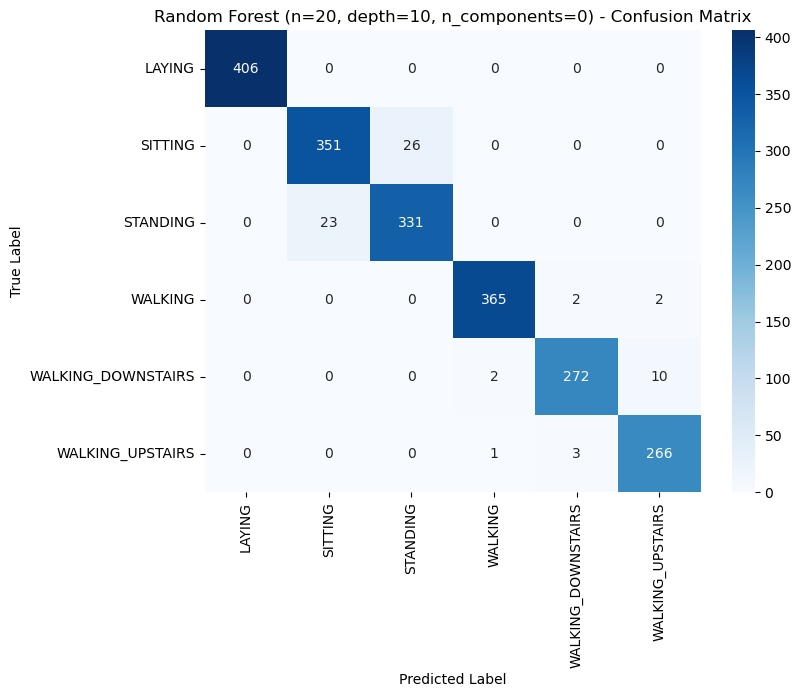

In [5]:
rfmodel, _, _, _, _ = train_forest(estimators=20,
             depth=10,
             X_train=X_train,
             y_train=y_train,
             X_test=X_test,
             y_test=y_test,
             class_labels=label_encoder.classes_,
             n_components=0)

In [6]:
# Get feature importances
importances = rfmodel.feature_importances_

# Get indices of top 25 important features
indices = np.argsort(importances)[-25:][::-1]

# Get feature names
feature_names = data.columns[:-1]  # Exclude the target column 'Activity'

# Print the top 20 features and their importances
top_features = [(feature_names[i], importances[i]) for i in indices]
for feature, importance in top_features:
    print(f"{feature}: {importance:.4f}")

angle(X,gravityMean): 0.0542
tGravityAcc-mean()-Y: 0.0366
tGravityAcc-min()-X: 0.0305
fBodyAccJerk-bandsEnergy()-1,16: 0.0265
tGravityAcc-mean()-X: 0.0261
tGravityAcc-energy()-X: 0.0228
tBodyAccJerk-std()-X: 0.0213
tGravityAcc-max()-X: 0.0213
tBodyGyroJerk-iqr()-Z: 0.0211
tBodyAccJerk-sma(): 0.0210
fBodyAccJerk-bandsEnergy()-1,16.1: 0.0209
tGravityAcc-max()-Y: 0.0204
tGravityAccMag-std(): 0.0189
tBodyAcc-max()-X: 0.0184
tBodyAcc-std()-X: 0.0171
fBodyAccJerk-bandsEnergy()-1,8: 0.0163
tGravityAcc-min()-Y: 0.0155
angle(Y,gravityMean): 0.0153
tGravityAcc-arCoeff()-X,1: 0.0148
tGravityAcc-arCoeff()-Z,2: 0.0143
tGravityAcc-energy()-Y: 0.0140
tBodyAccJerk-mad()-Y: 0.0119
tBodyAcc-energy()-X: 0.0111
fBodyAccMag-mad(): 0.0109
fBodyAccJerk-bandsEnergy()-9,16: 0.0109


In [7]:
# Get bottom 25 features
indices = np.argsort(importances)[:25]
bottom_features = [(feature_names[i], importances[i]) for i in indices]
for feature, importance in bottom_features:
    print(f"{feature}: {importance}")

# Get number of feature importances that rounded to 2 digits >= 0.01
print("--------------------------------------------")
print(f"Number of important features (larger than 1%): {sum(importances >= 0.01)}")
print(f"Number of important features (larger than 0.1%): {sum(importances >= 0.001)}")
print(f"Total number of features: {len(importances)}")

fBodyBodyAccJerkMag-maxInds: 0.0
fBodyAccJerk-bandsEnergy()-49,56: 0.0
fBodyAccJerk-entropy()-Z: 0.0
fBodyAccJerk-bandsEnergy()-33,40.2: 2.003992062605338e-19
fBodyAccJerk-bandsEnergy()-25,48.1: 2.0240175923739862e-19
fBodyBodyGyroJerkMag-sma(): 3.8197814577521297e-19
fBodyAcc-bandsEnergy()-25,32: 3.2153838106588088e-06
tBodyAcc-min()-Z: 8.80330050140917e-06
tBodyGyro-arCoeff()-X,2: 9.249967309200676e-06
fBodyAccJerk-bandsEnergy()-49,56.1: 1.022053301035911e-05
fBodyGyro-mad()-Z: 1.1706890471697677e-05
fBodyAccMag-min(): 1.2869188455716615e-05
fBodyAccJerk-bandsEnergy()-57,64: 1.435531336682225e-05
fBodyAccJerk-maxInds-Y: 1.5365728188888223e-05
fBodyAcc-bandsEnergy()-17,24.1: 1.6767479285065876e-05
fBodyAcc-entropy()-Z: 1.9992888311372568e-05
tBodyAccJerk-arCoeff()-Y,2: 2.323186734878901e-05
fBodyAcc-bandsEnergy()-41,48.1: 2.5380081867662048e-05
tBodyAcc-arCoeff()-Y,3: 2.541426394076495e-05
tBodyGyroJerk-mean()-Y: 2.556708404636204e-05
fBodyAcc-bandsEnergy()-57,64.1: 2.8333581902560948

In [8]:
pca_model = PCA(n_components= 8)
pca_model.fit(X_train)
print(pca_model.explained_variance_ratio_)
print(pca_model.explained_variance_)
print(pca_model.singular_values_)

[0.50801854 0.06237329 0.02631659 0.02443171 0.01905611 0.01628338
 0.01403286 0.01221456]
[284.00629927  34.86960626  14.71221089  13.65847937  10.65326354
   9.1031758    7.84503156   6.82851657]
[1529.58945257  535.96251396  348.1367451   335.43785268  296.24581856
  273.84660355  254.21913778  237.17782256]


In [9]:
pca_model.get_feature_names_out()

array(['pca0', 'pca1', 'pca2', 'pca3', 'pca4', 'pca5', 'pca6', 'pca7'],
      dtype=object)

In [10]:
pca_model.get_covariance()

array([[ 0.41085811, -0.01598843, -0.04897782, ..., -0.04863297,
         0.01962699,  0.02518383],
       [-0.01598843,  0.32988507,  0.01482665, ...,  0.00219445,
        -0.01051871, -0.01722385],
       [-0.04897782,  0.01482665,  0.35677764, ...,  0.02418732,
        -0.02472449, -0.02487268],
       ...,
       [-0.04863297,  0.00219445,  0.02418732, ...,  1.13867046,
        -0.73621584, -0.66785433],
       [ 0.01962699, -0.01051871, -0.02472449, ..., -0.73621584,
         1.03338433,  0.62826948],
       [ 0.02518383, -0.01722385, -0.02487268, ..., -0.66785433,
         0.62826948,  0.97880874]])

Accuracy: 0.8442
Sensitivity: 0.8473
Specificity: 0.9688
F1 Score: 0.8442

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       406
           1       0.75      0.60      0.67       377
           2       0.69      0.84      0.76       354
           3       0.94      0.90      0.92       369
           4       0.85      0.87      0.86       284
           5       0.89      0.91      0.90       270

    accuracy                           0.84      2060
   macro avg       0.85      0.85      0.84      2060
weighted avg       0.85      0.84      0.84      2060



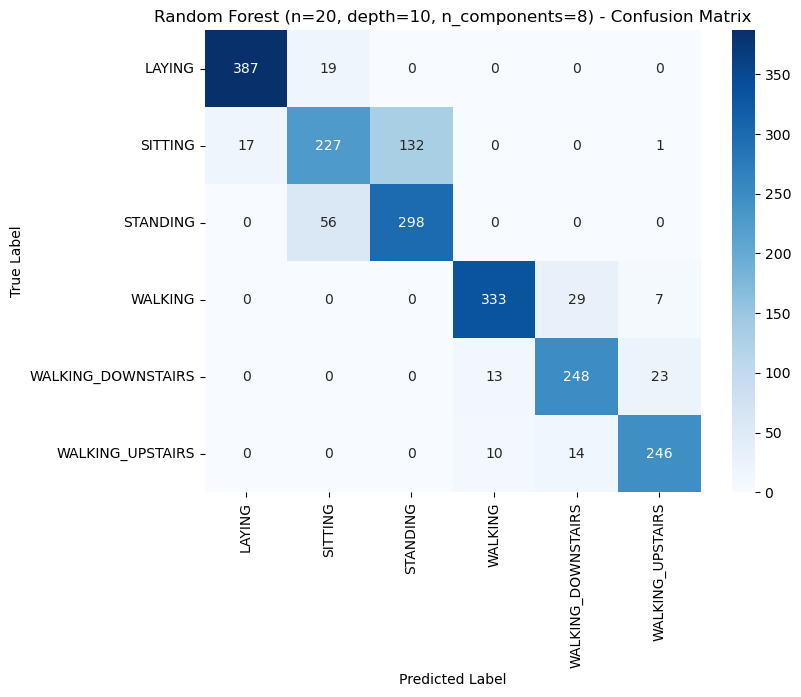

(RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=20,
                        random_state=42),
 0.8441747572815534,
 0.847320244680677,
 0.9687755109209412,
 0.8441784858599193)

In [11]:
X_train_pca = pca_model.transform(X_train)
train_forest(estimators=20,
             depth=10,
             X_train=X_train_pca,
             y_train=y_train,
             X_test=pca_model.transform(X_test),
             y_test=y_test,
             class_labels=label_encoder.classes_,
             n_components=8)

Cumulative Variance Ratio: 0.5080185445744887
Explained Variance: [284.00629927]
Explained Variance Ratio: [0.50801854]
Accuracy: 0.3981
Sensitivity: 0.4020
Specificity: 0.8792
F1 Score: 0.3990

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.45      0.44       406
           1       0.32      0.30      0.31       377
           2       0.39      0.41      0.40       354
           3       0.41      0.35      0.37       369
           4       0.47      0.50      0.48       284
           5       0.36      0.41      0.39       270

    accuracy                           0.40      2060
   macro avg       0.40      0.40      0.40      2060
weighted avg       0.40      0.40      0.40      2060



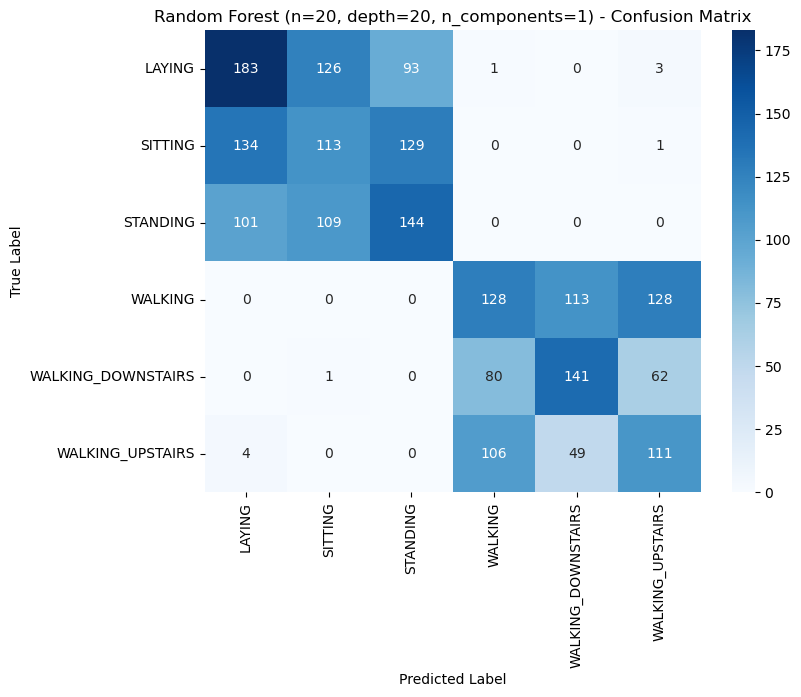

Cumulative Variance Ratio: 0.5703918323049735
Explained Variance: [284.00629927  34.86960626]
Explained Variance Ratio: [0.50801854 0.06237329]
Accuracy: 0.5262
Sensitivity: 0.5366
Specificity: 0.9046
F1 Score: 0.5315

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.47      0.49       406
           1       0.36      0.29      0.32       377
           2       0.40      0.52      0.45       354
           3       0.68      0.70      0.69       369
           4       0.56      0.48      0.51       284
           5       0.68      0.76      0.72       270

    accuracy                           0.53      2060
   macro avg       0.53      0.54      0.53      2060
weighted avg       0.52      0.53      0.52      2060



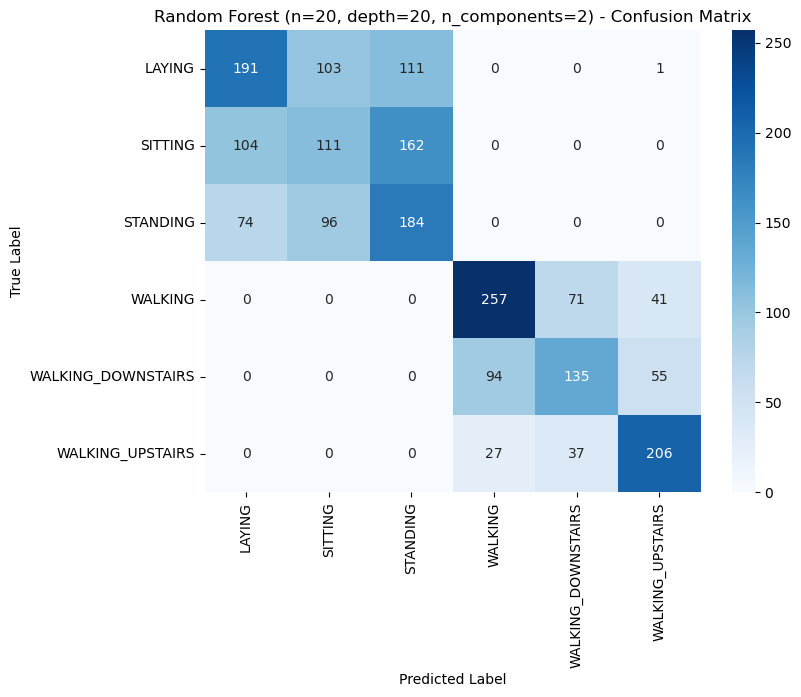

Cumulative Variance Ratio: 0.5967084174585895
Explained Variance: [284.00629927  34.86960626  14.71221088]
Explained Variance Ratio: [0.50801854 0.06237329 0.02631659]
Accuracy: 0.6762
Sensitivity: 0.6758
Specificity: 0.9351
F1 Score: 0.6694

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.85       406
           1       0.53      0.41      0.46       377
           2       0.56      0.64      0.60       354
           3       0.75      0.73      0.74       369
           4       0.61      0.58      0.59       284
           5       0.74      0.81      0.78       270

    accuracy                           0.68      2060
   macro avg       0.67      0.68      0.67      2060
weighted avg       0.67      0.68      0.67      2060



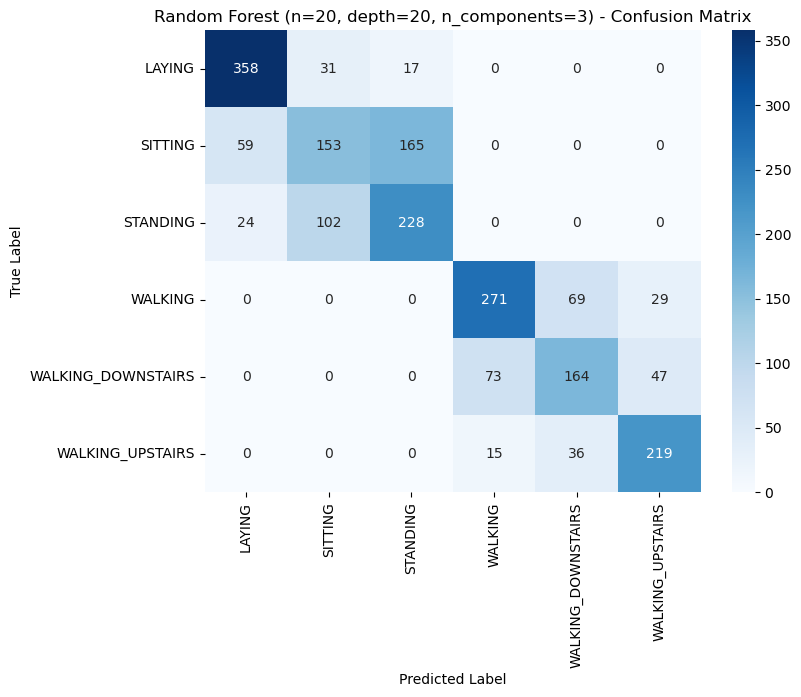

Cumulative Variance Ratio: 0.6211401319158177
Explained Variance: [284.00629927  34.86960626  14.71221088  13.65847936]
Explained Variance Ratio: [0.50801854 0.06237329 0.02631659 0.02443171]
Accuracy: 0.7830
Sensitivity: 0.7817
Specificity: 0.9566
F1 Score: 0.7780

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92       406
           1       0.69      0.54      0.60       377
           2       0.65      0.81      0.72       354
           3       0.89      0.87      0.88       369
           4       0.75      0.73      0.74       284
           5       0.78      0.83      0.80       270

    accuracy                           0.78      2060
   macro avg       0.78      0.78      0.78      2060
weighted avg       0.78      0.78      0.78      2060



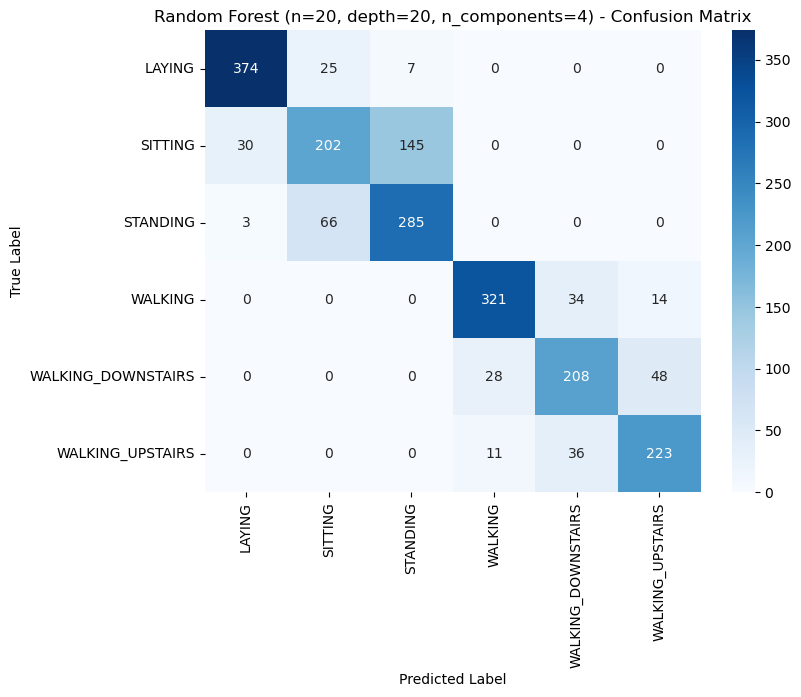

Cumulative Variance Ratio: 0.6401962418757954
Explained Variance: [284.00629927  34.86960626  14.71221081  13.65847917  10.65326347]
Explained Variance Ratio: [0.50801854 0.06237329 0.02631659 0.02443171 0.01905611]
Accuracy: 0.8180
Sensitivity: 0.8150
Specificity: 0.9637
F1 Score: 0.8120

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.96       406
           1       0.75      0.63      0.69       377
           2       0.71      0.82      0.76       354
           3       0.91      0.88      0.89       369
           4       0.78      0.73      0.76       284
           5       0.78      0.86      0.82       270

    accuracy                           0.82      2060
   macro avg       0.81      0.81      0.81      2060
weighted avg       0.82      0.82      0.82      2060



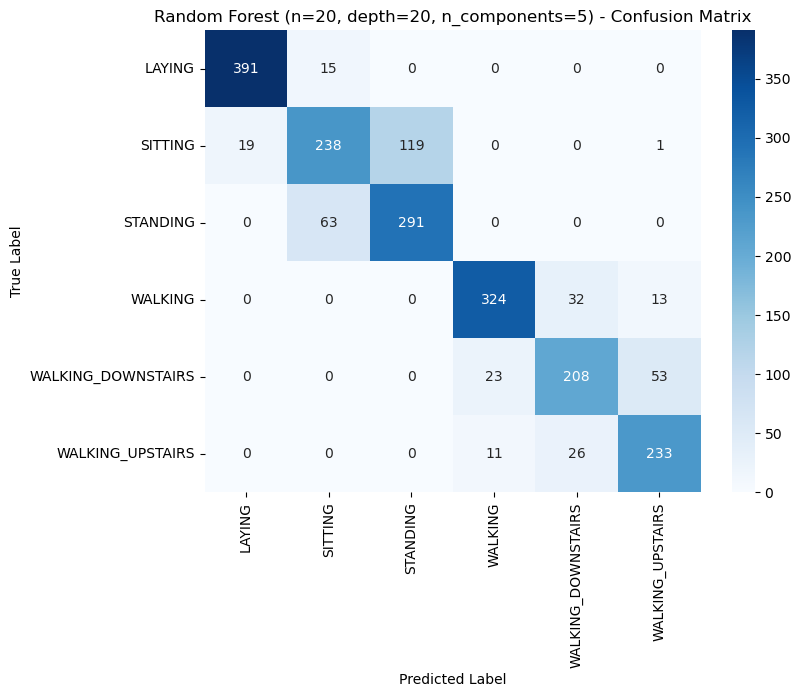

Cumulative Variance Ratio: 0.6564796219945945
Explained Variance: [284.00629927  34.86960626  14.71221089  13.65847936  10.65326345
   9.10317635]
Explained Variance Ratio: [0.50801854 0.06237329 0.02631659 0.02443171 0.01905611 0.01628338]
Accuracy: 0.8354
Sensitivity: 0.8358
Specificity: 0.9671
F1 Score: 0.8334

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95       406
           1       0.75      0.63      0.69       377
           2       0.71      0.84      0.77       354
           3       0.91      0.89      0.90       369
           4       0.82      0.82      0.82       284
           5       0.86      0.89      0.87       270

    accuracy                           0.84      2060
   macro avg       0.83      0.84      0.83      2060
weighted avg       0.84      0.84      0.83      2060



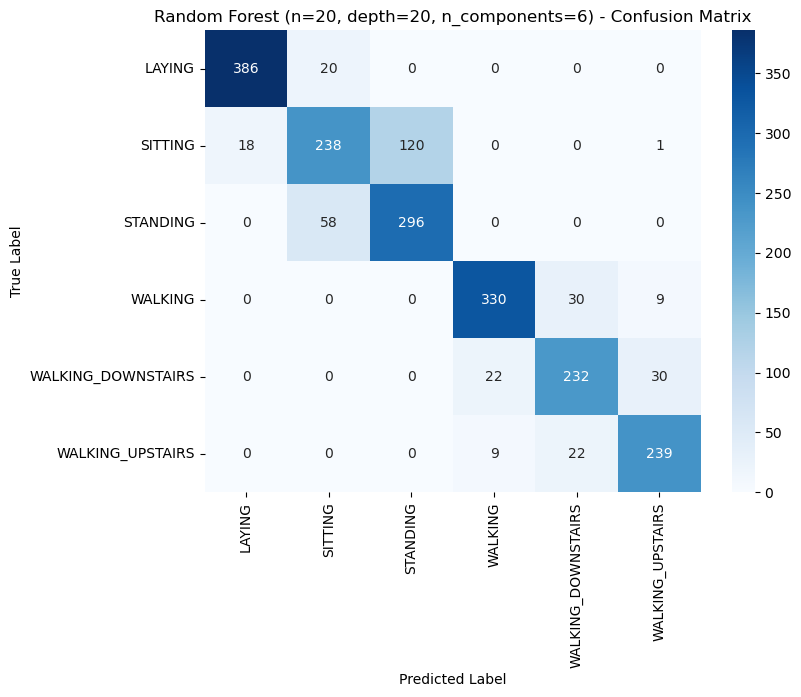

Cumulative Variance Ratio: 0.6705124489791923
Explained Variance: [284.00629927  34.86960626  14.71221089  13.65847936  10.65326335
   9.10317119   7.84501663]
Explained Variance Ratio: [0.50801854 0.06237329 0.02631659 0.02443171 0.01905611 0.01628337
 0.01403284]
Accuracy: 0.8481
Sensitivity: 0.8487
Specificity: 0.9696
F1 Score: 0.8467

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       406
           1       0.76      0.64      0.69       377
           2       0.71      0.83      0.77       354
           3       0.93      0.93      0.93       369
           4       0.87      0.82      0.85       284
           5       0.87      0.91      0.89       270

    accuracy                           0.85      2060
   macro avg       0.85      0.85      0.85      2060
weighted avg       0.85      0.85      0.85      2060



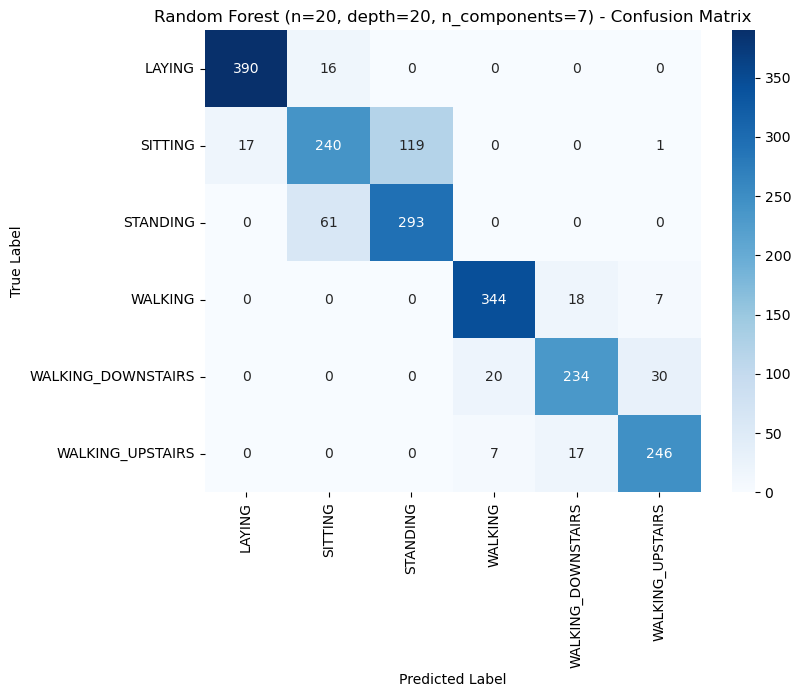

Cumulative Variance Ratio: 0.6827270770114453
Explained Variance: [284.00629927  34.86960626  14.71221089  13.65847936  10.65326339
   9.10317639   7.84503364   6.82853025]
Explained Variance Ratio: [0.50801854 0.06237329 0.02631659 0.02443171 0.01905611 0.01628338
 0.01403287 0.01221459]
Accuracy: 0.8602
Sensitivity: 0.8628
Specificity: 0.9719
F1 Score: 0.8609

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       406
           1       0.76      0.64      0.69       377
           2       0.71      0.82      0.77       354
           3       0.95      0.94      0.95       369
           4       0.89      0.88      0.88       284
           5       0.91      0.93      0.92       270

    accuracy                           0.86      2060
   macro avg       0.86      0.86      0.86      2060
weighted avg       0.86      0.86      0.86      2060



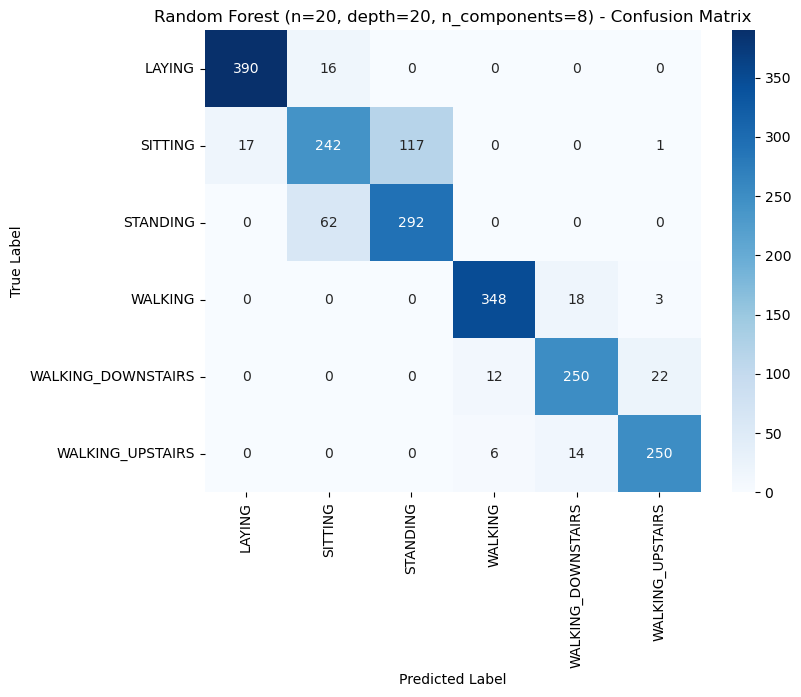

Cumulative Variance Ratio: 0.6926097840929145
Explained Variance: [284.00629927  34.86960626  14.71221089  13.65847936  10.65326351
   9.10317629   7.84502828   6.82855467   5.52487976]
Explained Variance Ratio: [0.50801854 0.06237329 0.02631659 0.02443171 0.01905611 0.01628338
 0.01403286 0.01221463 0.00988267]
Accuracy: 0.8636
Sensitivity: 0.8674
Specificity: 0.9726
F1 Score: 0.8660

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       406
           1       0.75      0.64      0.69       377
           2       0.71      0.82      0.76       354
           3       0.95      0.95      0.95       369
           4       0.90      0.92      0.91       284
           5       0.94      0.92      0.93       270

    accuracy                           0.86      2060
   macro avg       0.87      0.87      0.87      2060
weighted avg       0.87      0.86      0.86      2060



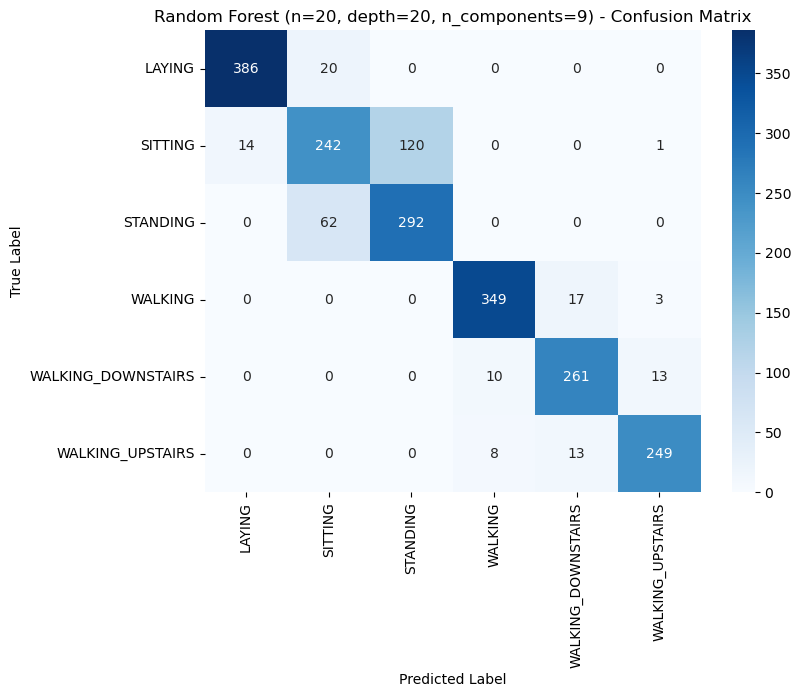

Cumulative Variance Ratio: 0.702228601098762
Explained Variance: [284.00629927  34.86960626  14.71221089  13.65847936  10.65326357
   9.10317654   7.8450316    6.82856102   5.52545564   5.37678599]
Explained Variance Ratio: [0.50801854 0.06237329 0.02631659 0.02443171 0.01905611 0.01628338
 0.01403286 0.01221464 0.0098837  0.00961777]
Accuracy: 0.8743
Sensitivity: 0.8777
Specificity: 0.9747
F1 Score: 0.8764

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.96       406
           1       0.76      0.68      0.72       377
           2       0.73      0.83      0.78       354
           3       0.96      0.95      0.96       369
           4       0.90      0.92      0.91       284
           5       0.93      0.93      0.93       270

    accuracy                           0.87      2060
   macro avg       0.88      0.88      0.88      2060
weighted avg       0.88      0.87      0.87      2060



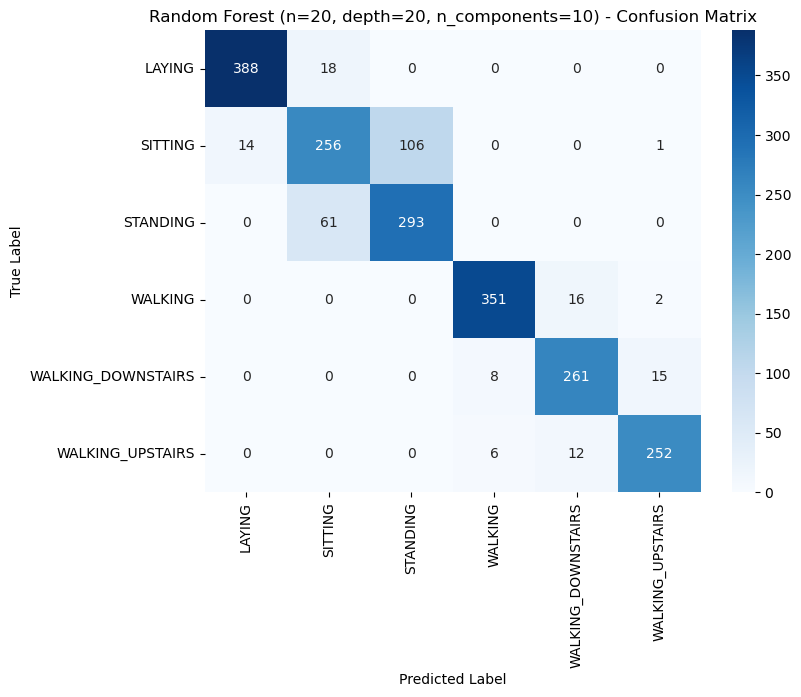

Cumulative Variance Ratio: 0.7107739713883464
Explained Variance: [284.00629927  34.86960626  14.71221089  13.65847937  10.65326356
   9.10317671   7.84503209   6.82845186   5.52542722   5.37660343
   4.77758406]
Explained Variance Ratio: [0.50801854 0.06237329 0.02631659 0.02443171 0.01905611 0.01628338
 0.01403286 0.01221445 0.00988365 0.00961744 0.00854594]
Accuracy: 0.8762
Sensitivity: 0.8795
Specificity: 0.9751
F1 Score: 0.8783

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96       406
           1       0.77      0.66      0.71       377
           2       0.72      0.82      0.77       354
           3       0.95      0.96      0.96       369
           4       0.93      0.93      0.93       284
           5       0.94      0.93      0.94       270

    accuracy                           0.88      2060
   macro avg       0.88      0.88      0.88      2060
weighted avg       0.88      0.88      0.88      2

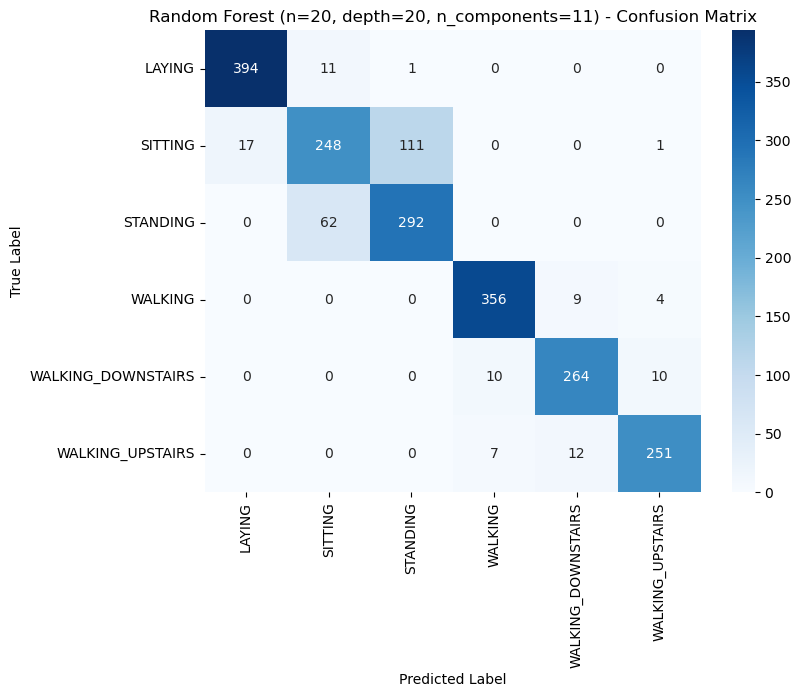

Cumulative Variance Ratio: 0.7188986794315135
Explained Variance: [284.00629927  34.86960626  14.71221089  13.65847936  10.65326359
   9.10317672   7.84503348   6.82856879   5.52537912   5.37687542
   4.78043417   4.53890218]
Explained Variance Ratio: [0.50801854 0.06237329 0.02631659 0.02443171 0.01905611 0.01628338
 0.01403287 0.01221466 0.00988357 0.00961793 0.00855104 0.008119  ]
Accuracy: 0.8825
Sensitivity: 0.8859
Specificity: 0.9764
F1 Score: 0.8845

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.97       406
           1       0.80      0.68      0.74       377
           2       0.74      0.84      0.79       354
           3       0.95      0.95      0.95       369
           4       0.92      0.93      0.92       284
           5       0.95      0.94      0.94       270

    accuracy                           0.88      2060
   macro avg       0.89      0.89      0.88      2060
weighted avg       0.88   

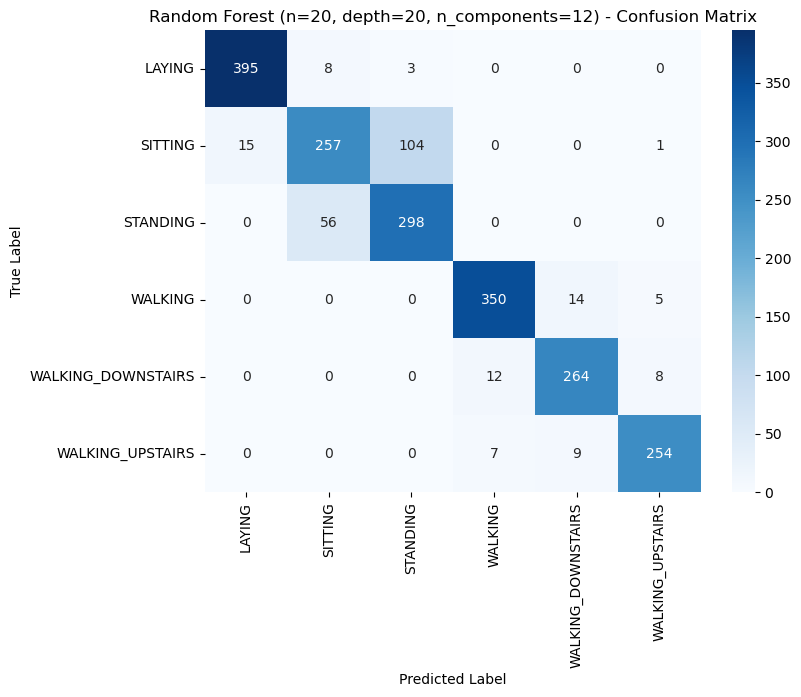

Cumulative Variance Ratio: 0.72674968249363
Explained Variance: [284.00629927  34.86960626  14.71221089  13.65847937  10.65326359
   9.10317655   7.84503428   6.82856835   5.52550056   5.37680079
   4.78070671   4.53994142   4.38772181]
Explained Variance Ratio: [0.50801854 0.06237329 0.02631659 0.02443171 0.01905611 0.01628338
 0.01403287 0.01221466 0.00988378 0.0096178  0.00855153 0.00812086
 0.00784857]
Accuracy: 0.8806
Sensitivity: 0.8841
Specificity: 0.9759
F1 Score: 0.8829

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       406
           1       0.78      0.67      0.72       377
           2       0.73      0.83      0.77       354
           3       0.95      0.96      0.95       369
           4       0.95      0.93      0.94       284
           5       0.94      0.94      0.94       270

    accuracy                           0.88      2060
   macro avg       0.88      0.88      0.88      2060
wei

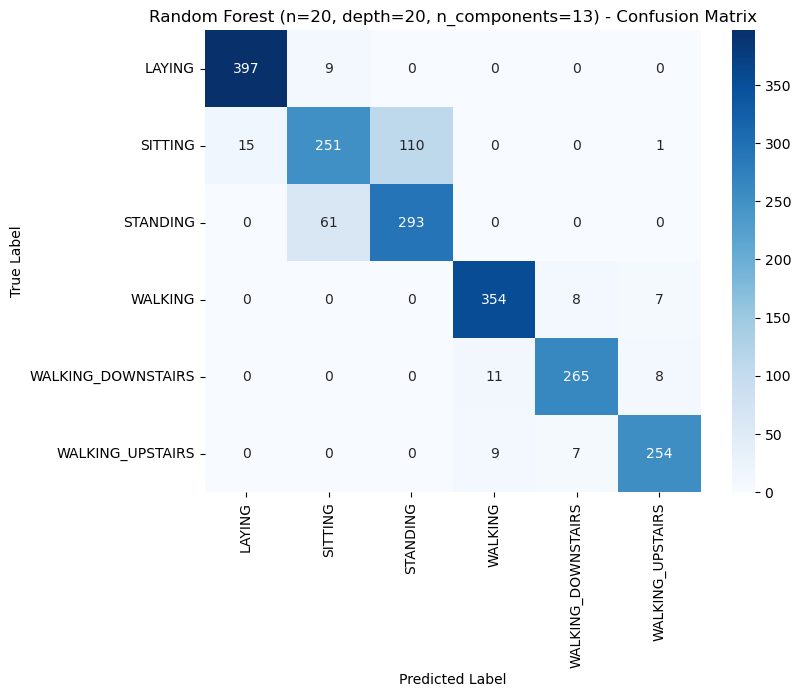

Cumulative Variance Ratio: 0.7334407164065871
Explained Variance: [284.00629927  34.86960626  14.71221089  13.65847937  10.65326359
   9.10317677   7.84503502   6.82857006   5.52548693   5.37687452
   4.78070031   4.54058322   4.38792148   3.73970533]
Explained Variance Ratio: [0.50801854 0.06237329 0.02631659 0.02443171 0.01905611 0.01628338
 0.01403287 0.01221466 0.00988376 0.00961793 0.00855152 0.008122
 0.00784893 0.00668943]
Accuracy: 0.8888
Sensitivity: 0.8928
Specificity: 0.9776
F1 Score: 0.8917

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       406
           1       0.78      0.69      0.73       377
           2       0.75      0.82      0.78       354
           3       0.97      0.96      0.97       369
           4       0.93      0.95      0.94       284
           5       0.97      0.95      0.96       270

    accuracy                           0.89      2060
   macro avg       0.89      0.89

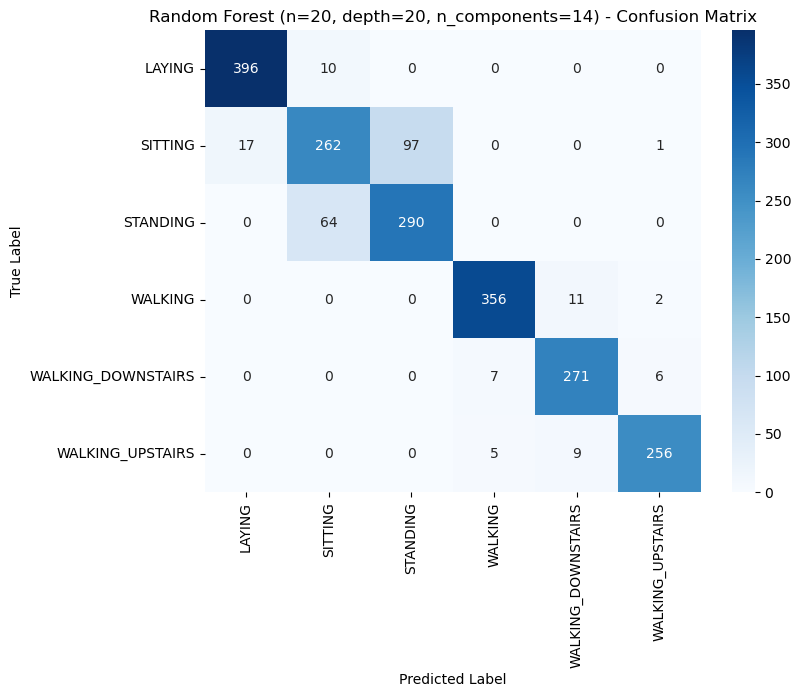

Cumulative Variance Ratio: 0.7397416718610702
Explained Variance: [284.00629927  34.86960626  14.71221089  13.65847937  10.65326358
   9.10317675   7.8450351    6.82856625   5.52549347   5.37685923
   4.78038505   4.54040394   4.38804697   3.73043525   3.53218258]
Explained Variance Ratio: [0.50801854 0.06237329 0.02631659 0.02443171 0.01905611 0.01628338
 0.01403287 0.01221465 0.00988377 0.0096179  0.00855095 0.00812168
 0.00784915 0.00667285 0.00631822]
Accuracy: 0.8966
Sensitivity: 0.8999
Specificity: 0.9792
F1 Score: 0.8992

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97       406
           1       0.80      0.72      0.76       377
           2       0.76      0.82      0.79       354
           3       0.96      0.97      0.96       369
           4       0.96      0.94      0.95       284
           5       0.95      0.96      0.95       270

    accuracy                           0.90      2060
   macr

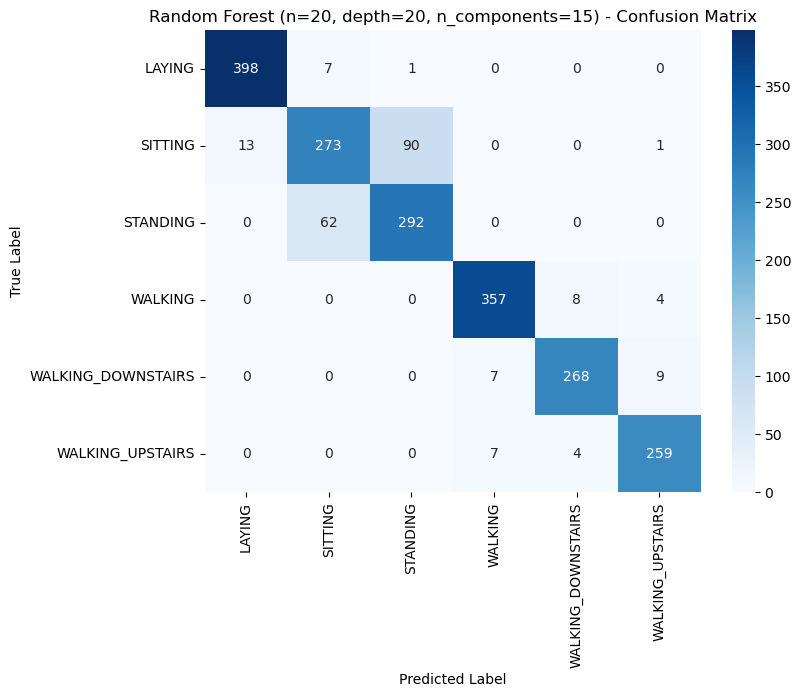

Cumulative Variance Ratio: 0.7459812899725963
Explained Variance: [284.00629927  34.86960626  14.71221089  13.65847937  10.65326359
   9.10317677   7.84503519   6.82857026   5.52549093   5.37688689
   4.78066853   4.54056579   4.38818326   3.74000504   3.55294711
   3.45729527]
Explained Variance Ratio: [0.50801854 0.06237329 0.02631659 0.02443171 0.01905611 0.01628338
 0.01403287 0.01221466 0.00988377 0.00961795 0.00855146 0.00812197
 0.0078494  0.00668996 0.00635536 0.00618426]
Accuracy: 0.8942
Sensitivity: 0.8977
Specificity: 0.9787
F1 Score: 0.8968

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       406
           1       0.79      0.72      0.75       377
           2       0.77      0.81      0.79       354
           3       0.96      0.97      0.97       369
           4       0.96      0.94      0.95       284
           5       0.95      0.96      0.95       270

    accuracy                        

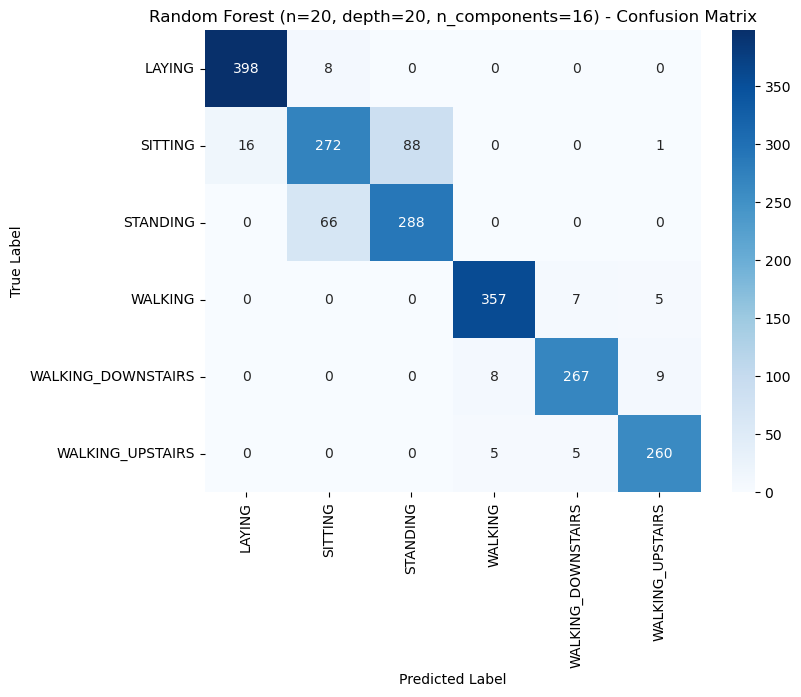

+--------------+----------+-------------+-------------+----------+-------------------------------+----------------------+------------+
| n_components | Accuracy | Sensitivity | Specificity | F1 Score | Cumulative Explained Variance | Reconstruction Error | Time Taken |
+--------------+----------+-------------+-------------+----------+-------------------------------+----------------------+------------+
|      1       |  0.3981  |    0.402    |   0.8792    |  0.399   |             0.508             |        0.4902        |   0.766    |
|      2       |  0.5262  |   0.5366    |   0.9046    |  0.5315  |            0.5704             |        0.4281        |   0.7265   |
|      3       |  0.6762  |   0.6758    |   0.9351    |  0.6694  |            0.5967             |        0.4018        |   0.6013   |
|      4       |  0.783   |   0.7817    |   0.9566    |  0.778   |            0.6211             |        0.3775        |   0.8165   |
|      5       |  0.818   |    0.815    |   0.9637    |

In [12]:
from datetime import datetime

results = []
def dimension_reduce_random_classify(n_components, estimators, depth, X_train, y_train, X_test, y_test):
    # Start timer
    start = datetime.now()

    pca_model = PCA(n_components=n_components)
    X_train_pca = pca_model.fit_transform(X_train)

    X_train_reconstructed = pca_model.inverse_transform(X_train_pca)
    error = mean_squared_error(X_train, X_train_reconstructed)

    cum_variance_ratio = pca_model.explained_variance_ratio_.sum()
    print(f"Cumulative Variance Ratio: {cum_variance_ratio}")
    print(f"Explained Variance: {pca_model.explained_variance_}")
    print(f"Explained Variance Ratio: {pca_model.explained_variance_ratio_}")
    _, accuracy, sensitivity, specificity, f1 = train_forest(estimators=estimators,
                depth=depth,
                X_train=X_train_pca,
                y_train=y_train,
                X_test=pca_model.transform(X_test),
                y_test=y_test,
                class_labels=label_encoder.classes_,
                n_components=n_components)
    # End timer
    end = datetime.now()
    # Calculate time taken in seconds
    time_taken = (end - start).total_seconds()

    # Round all values in one step using map()
    results.append(tuple(map(lambda x: round(x, 4), [n_components, accuracy, sensitivity, specificity, f1, cum_variance_ratio, error, time_taken])))

for n_components in range(1,17): # From 0 to 16
    dimension_reduce_random_classify(n_components=n_components,
                                     estimators=20,
                                     depth=20,
                                     X_train=X_train,
                                     y_train=y_train,
                                     X_test=X_test,
                                     y_test=y_test)
    
print(tabulate.tabulate(results, headers=["n_components", "Accuracy", "Sensitivity", "Specificity", "F1 Score", "Cumulative Explained Variance", "Reconstruction Error", "Time Taken"], tablefmt="pretty"))

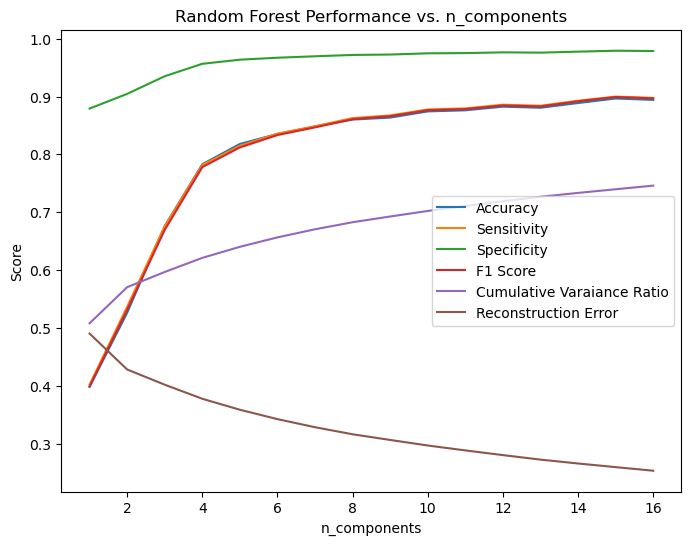

In [13]:
# plot everything against n_components
legend = {1:"Accuracy",
          2:"Sensitivity",
          3:"Specificity",
          4:"F1 Score",
          5:"Cumulative Varaiance Ratio",
          6:"Reconstruction Error"} 
results = np.array(results)

plt.figure(figsize=(8, 6))
for n in legend.keys():
    plt.plot(results[:, 0], results[:, n], label=legend[n])
plt.xlabel("n_components")
plt.ylabel("Score")
plt.title("Random Forest Performance vs. n_components")
plt.legend()
plt.show()

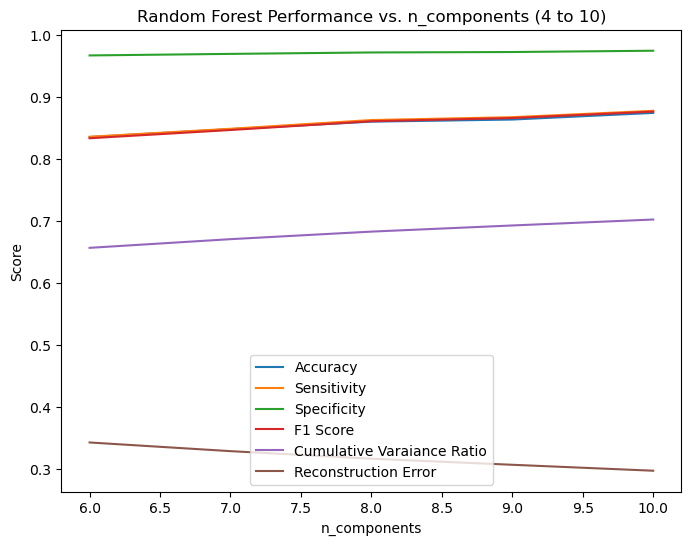

In [14]:
# Filter results for n_components between 6 and 10
filtered_results = results[(results[:, 0] >= 6) & (results[:, 0] <= 10)]

plt.figure(figsize=(8, 6))
for n in legend.keys():
    plt.plot(filtered_results[:, 0], filtered_results[:, n], label=legend[n])
plt.xlabel("n_components")
plt.ylabel("Score")
plt.title("Random Forest Performance vs. n_components (4 to 10)")
plt.legend()
plt.show()

### Find the optimized principal component number for prediction (accuracy/computation time, etc). Explain your reasons. 

The criteria for evaluating the most optimal principle component number for number includes:

- Accuracy: The capability to classify the true positive and false negative of each case in the classification dataset. The optimal n component for PCA is found when the accuracy gain start to diminish (elbow on the curve) 
- Cumulative variance ratio: Few components capture the most variance, but not neccessary all variance of the dataset
- Reconstruction error: Preserved data may be important for later. Smaller the error, the better the data preservation.
- Computation time: the shorter time, the better performance

Based on these criteria, the acceptable range can be narrowed down to 6 to 10 because of the plateau gain in accuracy, along with sensitity, specificity and F1 score. The cumulative variance ratio experiences marginal gain in this intervals. Reconstruction error also has a dimishing improvement. Computation time only increases from about 0.9 to 1.1 seconds. The optimal number of component can be 8 to balance between the accuracy and computation time, while other metrics are neglectable, because of small changes.


Cumulative Variance Ratio: 0.6827
Reconstruction Error: 0.3161
Accuracy: 0.8553
Sensitivity: 0.8577
Specificity: 0.9709
F1 Score: 0.8565

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96       406
           1       0.74      0.64      0.69       377
           2       0.71      0.80      0.75       354
           3       0.94      0.95      0.94       369
           4       0.88      0.88      0.88       284
           5       0.92      0.92      0.92       270

    accuracy                           0.86      2060
   macro avg       0.86      0.86      0.86      2060
weighted avg       0.86      0.86      0.85      2060



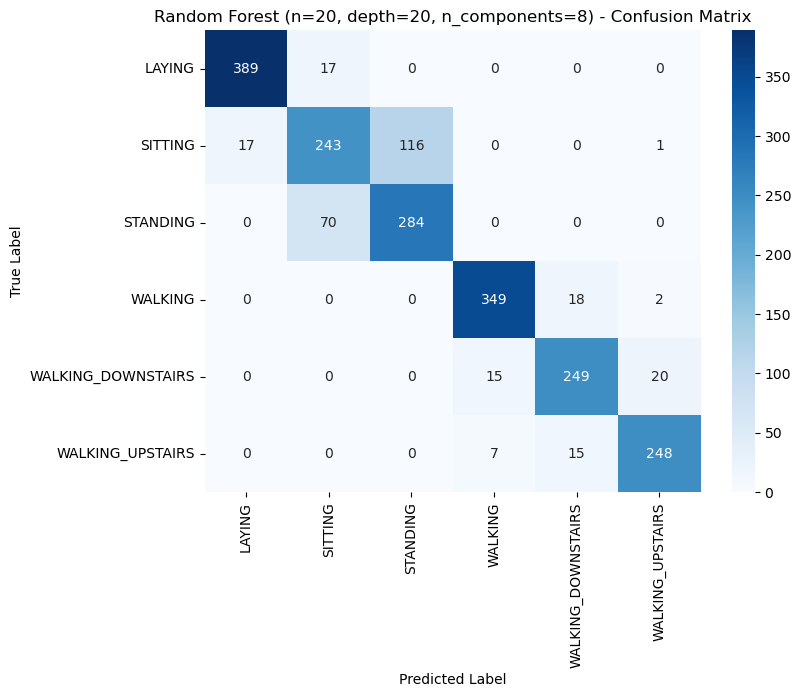

Time Taken: 0.8210 seconds


In [15]:
optimal_n = 8

start = datetime.now()
pca_model = PCA(n_components=optimal_n)
X_train_pca = pca_model.fit_transform(X_train)
X_train_reconstructed = pca_model.inverse_transform(X_train_pca)
error = mean_squared_error(X_train, X_train_reconstructed)
cum_variance_ratio = pca_model.explained_variance_ratio_.sum()

# print(f"Explained Variance: {pca_model.explained_variance_}")
# print(f"Explained Variance Ratio: {pca_model.explained_variance_ratio_}")
print(f"Cumulative Variance Ratio: {cum_variance_ratio:.4f}")
print(f"Reconstruction Error: {error:.4f}")

rfmodel, accuracy, sensitivity, specificity, f1 = train_forest(estimators=20,
                                                        depth=20,
                                                        X_train=X_train_pca,
                                                        y_train=y_train,
                                                        X_test=pca_model.transform(X_test),
                                                        y_test=y_test,
                                                        class_labels=label_encoder.classes_,
                                                        n_components=optimal_n)
end = datetime.now()
time_taken = (end - start).total_seconds()
print(f"Time Taken: {time_taken:.4f} seconds")

In [16]:
# Get feature importances
importances = rfmodel.feature_importances_

# Get indices of top 25 important features
indices = np.argsort(importances)[-25:][::-1]

# Get feature names
feature_names = data.columns[:-1]  # Exclude the target column 'Activity'

# Print the top 20 features and their importances
top_features = [(feature_names[i], importances[i]) for i in indices]
for feature, importance in top_features:
    print(f"{feature}: {importance:.4f}")

# Get number of feature importances that rounded to 2 digits >= 0.01
print("--------------------------------------------")
print(f"Number of important features (larger than 1%): {sum(importances >= 0.01)}")
print(f"Number of important features (larger than 0.1%): {sum(importances >= 0.001)}")
print(f"Total number of features: {len(importances)}")

tBodyAcc-mean()-X: 0.2283
tBodyAcc-std()-X: 0.1596
tBodyAcc-std()-Y: 0.1580
tBodyAcc-mean()-Y: 0.1209
tBodyAcc-mean()-Z: 0.1025
tBodyAcc-mad()-Y: 0.0787
tBodyAcc-mad()-X: 0.0784
tBodyAcc-std()-Z: 0.0736
--------------------------------------------
Number of important features (larger than 1%): 8
Number of important features (larger than 0.1%): 8
Total number of features: 8


### Compare and discuss the results in sections 10 and 3.

Straight random forest classification with 10 estimators and max depth of 10 metrics:

- Accuracy: 0.9665
- Sensitivity: 0.9664
- Specificity: 0.9933
- F1 Score: 0.9661
- Number of important features (larger than 1%): 34
- Number of important features (larger than 0.1%): 123
- Total number of features: 561

Random forest classification with 20 estimators and max depth of 20, after using PCA for dimenstionality reduction of 8 components:

- Cumulative Variance Ratio: 0.6827
- Reconstruction Error: 0.3161
- Accuracy: 0.8641
- Sensitivity: 0.8670
- Specificity: 0.9727
- F1 Score: 0.8658
- Time Taken: 0.9209 seconds
- Number of important features (larger than 1%): 8
- Number of important features (larger than 0.1%): 8
- Total number of features: 8

Based on the metrics, the straight forward random forest classification has better classification performance and better than random forest classfication model after dimenstionality reduction. The dimension reduction in this analysis may have harm the performance as the model experiences information loss and lacking of useful non-linear features to determine the output. The random forest model is designed to work in high dimensional dataset. Plus, there are 34 features that has more than 1% of model's decision making, which mean they are truely important features. In this scenario, feature selection can be a better approach as it matches the common goals of dimension reduction is to remove redundant features and reduce computation time. Based on the metrics provided, the straight forward random forest model can perform better that the combination of PCA and random forest model.